# Kunci Jawaban - Linear Regression

- **Dataset:** [Seoul Bike Sharing Demand](https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand)
- **Target:** `Rented Bike Count`
- **Jenis masalah:** Regression
- **Model:** Linear Regression

## 1 - Setup

### Install library tambahan

Install `ucimlrepo` terlebih dahulu agar dataset dari UCI Machine Learning Repository bisa diambil langsung di Google Colab.

In [1]:
%pip install -q ucimlrepo

### Import library utama

Import library utama berikut:

- `warnings`: mengatur tampilan warning.
- `numpy`: membantu perhitungan numerik, terutama RMSE.
- `pandas`: membaca, menyimpan, dan mengolah data berbentuk tabel.
- `matplotlib.pyplot`: membuat visualisasi dasar seperti histogram, bar plot, line plot, dan boxplot.
- `seaborn`: membuat visualisasi statistik seperti histogram dengan KDE, line plot, dan boxplot.

In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import fungsi dan class tambahan

Import fungsi dan class berikut dari package yang lebih besar:

- `fetch_ucirepo`: mengambil dataset langsung dari UCI Machine Learning Repository.
- `train_test_split`: membagi data menjadi data train dan data test.
- `StandardScaler`: menyamakan skala fitur numerik.
- `LinearRegression`: membuat dan melatih model regresi linear.
- `mean_absolute_error`: menghitung MAE.
- `mean_squared_error`: menghitung MSE dan RMSE.
- `r2_score`: menghitung R2 Score.

In [3]:
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Matikan warning yang tidak diperlukan

Matikan warning agar tampilan notebook lebih bersih.

In [4]:
warnings.filterwarnings("ignore")

### Atur tampilan angka

Atur tampilan angka agar tabel lebih mudah dibaca.

In [5]:
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="whitegrid")

## 2 - Load Dataset

### Ambil dataset dari UCI

Ambil dataset Seoul Bike Sharing Demand menggunakan ID dataset dari UCI.

In [6]:
seoul = fetch_ucirepo(id=560)

### Ambil fitur utama dari dataset

Simpan fitur utama dataset ke variabel `X_raw`.

In [7]:
X_raw = seoul.data.features.copy()

### Ambil informasi tambahan dari dataset

Simpan informasi `Functioning Day` ke variabel `extra_raw`.

In [8]:
extra_raw = seoul.data.targets.copy()

### Tentukan kolom target

Tentukan kolom `Rented Bike Count` sebagai target prediksi.

In [9]:
TARGET_COL = "Rented Bike Count"

### Gabungkan data dari UCI

Gabungkan fitur utama dan informasi tambahan menjadi satu DataFrame bernama `df`.

In [10]:
df = pd.concat([X_raw, extra_raw], axis=1)

### Tampilkan ukuran dataset

Tampilkan jumlah baris dan kolom pada dataset.

In [11]:
df.shape

(8760, 14)

> Berdasarkan output, berapa jumlah baris dan kolom pada dataset?

Jawaban: Dataset memiliki 8760 baris dan 14 kolom.

### Tampilkan lima baris pertama

Tampilkan lima baris pertama untuk melihat contoh isi data.

In [12]:
df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,1/12/2017,254,0,-5.200,37,2.200,2000,-17.600,0.000,0.000,0.000,Winter,No Holiday,Yes
1,1/12/2017,204,1,-5.500,38,0.800,2000,-17.600,0.000,0.000,0.000,Winter,No Holiday,Yes
2,1/12/2017,173,2,-6.000,39,1.000,2000,-17.700,0.000,0.000,0.000,Winter,No Holiday,Yes
3,1/12/2017,107,3,-6.200,40,0.900,2000,-17.600,0.000,0.000,0.000,Winter,No Holiday,Yes
4,1/12/2017,78,4,-6.000,36,2.300,2000,-18.600,0.000,0.000,0.000,Winter,No Holiday,Yes


> Berdasarkan lima baris pertama, kolom apa yang menjadi target prediksi?

Jawaban: Kolom target prediksi adalah `Rented Bike Count`.

> Kolom mana saja yang terlihat berisi kategori atau teks?

Jawaban: Kolom `Date`, `Seasons`, `Holiday`, dan `Functioning Day` berisi teks atau kategori.

## 3 - Data Understanding

### Tampilkan informasi dataset

Tampilkan informasi struktur dataset menggunakan `info()`.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   8760 non-null   object 
 1   Rented Bike Count      8760 non-null   int64  
 2   Hour                   8760 non-null   int64  
 3   Temperature            8760 non-null   float64
 4   Humidity               8760 non-null   int64  
 5   Wind speed             8760 non-null   float64
 6   Visibility             8760 non-null   int64  
 7   Dew point temperature  8760 non-null   float64
 8   Solar Radiation        8760 non-null   float64
 9   Rainfall               8760 non-null   float64
 10  Snowfall               8760 non-null   float64
 11  Seasons                8760 non-null   object 
 12  Holiday                8760 non-null   object 
 13  Functioning Day        8760 non-null   object 
dtypes: float64(6), int64(4), object(4)
memory usage: 958.3+ 

> Berdasarkan output `info()`, apa tipe data yang muncul pada dataset?

Jawaban: Dataset memiliki tipe data `object`, `int64`, dan `float64`.

> Apakah jumlah non-null menunjukkan adanya missing value?

Jawaban: Tidak. Semua kolom memiliki 8760 non-null, sama dengan jumlah baris dataset.

### Cek missing value

Hitung jumlah missing value pada setiap kolom.

In [14]:
df.isna().sum()

Date                     0
Rented Bike Count        0
Hour                     0
Temperature              0
Humidity                 0
Wind speed               0
Visibility               0
Dew point temperature    0
Solar Radiation          0
Rainfall                 0
Snowfall                 0
Seasons                  0
Holiday                  0
Functioning Day          0
dtype: int64

> Berdasarkan output, kolom mana yang memiliki missing value?

Jawaban: Tidak ada kolom yang memiliki missing value.

### Cek jumlah duplikat

Hitung jumlah baris duplikat penuh pada dataset.

In [15]:
df.duplicated().sum()

np.int64(0)

> Berdasarkan output, berapa jumlah baris duplikat penuh?

Jawaban: Jumlah baris duplikat penuh adalah 0.

### Tampilkan statistik deskriptif

Tampilkan statistik deskriptif untuk kolom numerik dan kategori.

In [16]:
df.describe(include="all")

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
count,8760,8760.000,8760.000,8760.000,8760.000,8760.000,8760.000,8760.000,8760.000,8760.000,8760.000,8760,8760,8760
unique,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,2
top,30/11/2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,No Holiday,Yes
freq,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2208,8328,8465
mean,NaN,704.602,11.500,12.883,58.226,1.725,1436.826,4.074,0.569,0.149,0.075,NaN,NaN,NaN
std,NaN,644.997,6.923,11.945,20.362,1.036,608.299,13.060,0.869,1.128,0.437,NaN,NaN,NaN
min,NaN,0.000,0.000,-17.800,0.000,0.000,27.000,-30.600,0.000,0.000,0.000,NaN,NaN,NaN
25%,NaN,191.000,5.750,3.500,42.000,0.900,940.000,-4.700,0.000,0.000,0.000,NaN,NaN,NaN
50%,NaN,504.500,11.500,13.700,57.000,1.500,1698.000,5.100,0.010,0.000,0.000,NaN,NaN,NaN
75%,NaN,1065.250,17.250,22.500,74.000,2.300,2000.000,14.800,0.930,0.000,0.000,NaN,NaN,NaN


> Berdasarkan statistik deskriptif, berapa rata-rata target `Rented Bike Count`?

Jawaban: Rata-rata target `Rented Bike Count` sekitar 704.602.

> Berdasarkan statistik deskriptif, kategori apa yang paling sering muncul pada kolom `Holiday`?

Jawaban: Kategori yang paling sering muncul pada kolom `Holiday` adalah `No Holiday`.

## 4 - Data Cleaning

### Hapus baris duplikat

Hapus baris duplikat penuh agar data lebih bersih.

In [17]:
df_clean = df.drop_duplicates().copy()

### Reset index dataset

Reset index setelah proses cleaning.

In [18]:
df_clean = df_clean.reset_index(drop=True)

### Cek ukuran data setelah cleaning

Tampilkan ukuran dataset setelah proses cleaning.

In [19]:
df_clean.shape

(8760, 14)

> Berdasarkan output, berapa ukuran dataset setelah duplikat dihapus?

Jawaban: Ukuran dataset tetap 8760 baris dan 14 kolom.

### Cek ulang duplikat

Pastikan tidak ada baris duplikat penuh setelah cleaning.

In [20]:
df_clean.duplicated().sum()

np.int64(0)

> Berdasarkan output, apakah masih ada baris duplikat setelah cleaning?

Jawaban: Tidak ada baris duplikat setelah cleaning.

## 5 - Exploratory Data Analysis

### Tampilkan statistik target

Tampilkan statistik deskriptif khusus untuk target `Rented Bike Count`.

In [21]:
df_clean[TARGET_COL].describe()

count   8760.000
mean     704.602
std      644.997
min        0.000
25%      191.000
50%      504.500
75%     1065.250
max     3556.000
Name: Rented Bike Count, dtype: float64

> Berdasarkan output, berapa nilai mean, minimum, dan maksimum target?

Jawaban: Mean target sekitar 704.602, minimum 0.000, dan maksimum 3556.000.

### Buat histogram target

Gunakan histogram dengan KDE untuk melihat distribusi target `Rented Bike Count`.

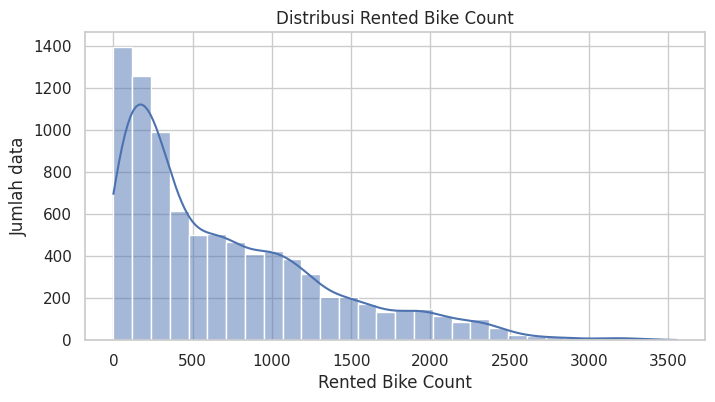

In [22]:
plt.figure(figsize=(8, 4))
sns.histplot(df_clean[TARGET_COL], bins=30, kde=True)
plt.title("Distribusi Rented Bike Count")
plt.xlabel("Rented Bike Count")
plt.ylabel("Jumlah data")
plt.show()

> Berdasarkan histogram, di rentang mana nilai target paling banyak muncul?

Jawaban: Nilai target paling banyak muncul pada rentang rendah, terutama sekitar 0 sampai 119 penyewaan.

> Apakah distribusi target terlihat simetris atau cenderung miring?

Jawaban: Distribusi target cenderung miring ke kanan karena ada nilai penyewaan yang jauh lebih tinggi.

### Hitung korelasi fitur numerik dengan target

Hitung korelasi fitur numerik terhadap target `Rented Bike Count`.

In [23]:
numeric_corr = df_clean.select_dtypes(include="number").corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
numeric_corr

Temperature              0.539
Hour                     0.410
Dew point temperature    0.380
Solar Radiation          0.262
Visibility               0.199
Wind speed               0.121
Rainfall                -0.123
Snowfall                -0.142
Humidity                -0.200
Name: Rented Bike Count, dtype: float64

> Berdasarkan output korelasi, fitur numerik apa yang memiliki korelasi positif paling tinggi terhadap target?

Jawaban: Fitur `Temperature` memiliki korelasi positif paling tinggi terhadap target.

> Fitur numerik apa yang memiliki korelasi negatif paling kuat terhadap target?

Jawaban: Fitur `Humidity` memiliki korelasi negatif paling kuat terhadap target.

### Buat bar plot korelasi numerik

Gunakan bar plot untuk melihat kekuatan korelasi fitur numerik dengan target.

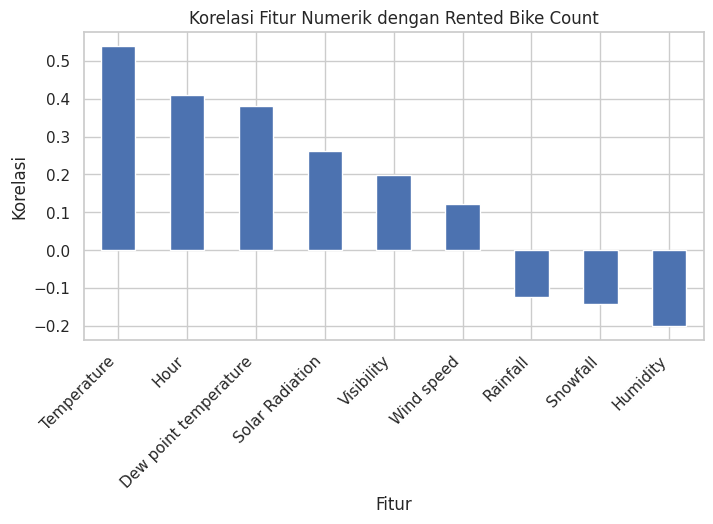

In [24]:
plt.figure(figsize=(8, 4))
numeric_corr.plot(kind="bar")
plt.title("Korelasi Fitur Numerik dengan Rented Bike Count")
plt.xlabel("Fitur")
plt.ylabel("Korelasi")
plt.xticks(rotation=45, ha="right")
plt.show()

> Berdasarkan bar plot, fitur mana yang terlihat paling positif hubungannya dengan target?

Jawaban: `Temperature` terlihat paling positif hubungannya dengan target.

> Fitur mana yang terlihat paling negatif hubungannya dengan target?

Jawaban: `Humidity` terlihat paling negatif hubungannya dengan target.

### Buat line plot rata-rata target berdasarkan Hour

Gunakan line plot untuk melihat rata-rata penyewaan sepeda pada setiap jam.

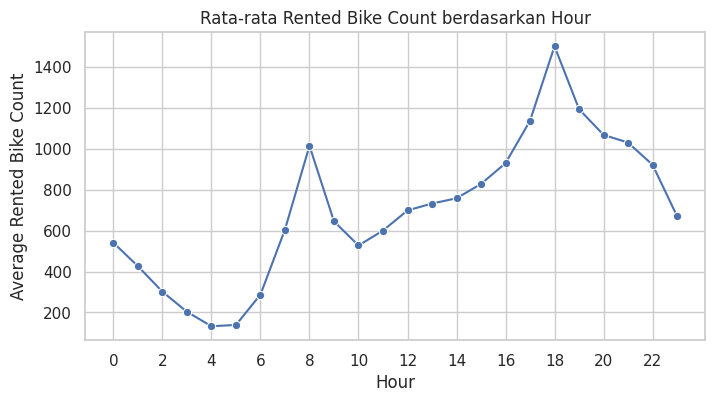

In [25]:
hour_mean = df_clean.groupby("Hour")[TARGET_COL].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.lineplot(data=hour_mean, x="Hour", y=TARGET_COL, marker="o")
plt.title("Rata-rata Rented Bike Count berdasarkan Hour")
plt.xlabel("Hour")
plt.ylabel("Average Rented Bike Count")
plt.xticks(range(0, 24, 2))
plt.show()

> Berdasarkan line plot, pada jam berapa rata-rata penyewaan terlihat paling tinggi?

Jawaban: Rata-rata penyewaan terlihat paling tinggi pada jam 18.

> Mengapa line plot lebih tepat daripada scatter plot untuk kolom `Hour`?

Jawaban: Line plot lebih tepat karena `Hour` adalah urutan waktu 0 sampai 23, sehingga pola rata-rata per jam lebih mudah dibaca sebagai tren harian.

### Buat boxplot target berdasarkan Seasons

Gunakan boxplot untuk membandingkan persebaran target pada setiap musim.

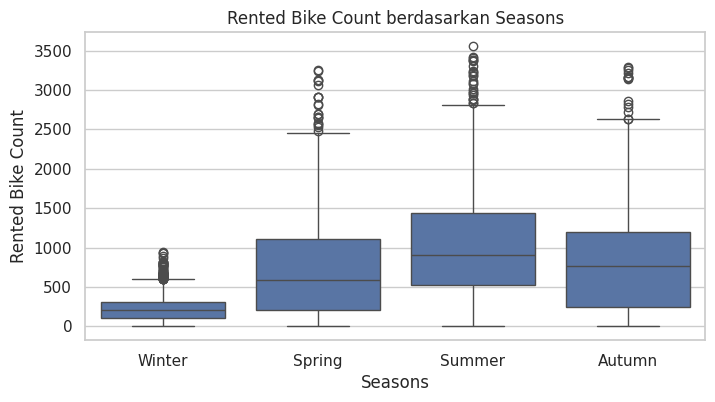

In [26]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clean, x="Seasons", y=TARGET_COL)
plt.title("Rented Bike Count berdasarkan Seasons")
plt.xlabel("Seasons")
plt.ylabel("Rented Bike Count")
plt.show()

> Berdasarkan boxplot, musim mana yang cenderung memiliki penyewaan lebih tinggi?

Jawaban: `Summer` cenderung memiliki penyewaan lebih tinggi.

> Musim mana yang cenderung memiliki penyewaan lebih rendah?

Jawaban: `Winter` cenderung memiliki penyewaan lebih rendah.

## 6 - Feature dan Target

### Pisahkan fitur awal

Pisahkan fitur awal dengan menghapus target dan kolom tanggal mentah.

In [27]:
X_raw_model = df_clean.drop(columns=[TARGET_COL, "Date"])

### Pisahkan target

Simpan kolom target ke dalam variabel `y`.

In [28]:
y = df_clean[TARGET_COL]

### Encode fitur kategori

Ubah kolom kategori menjadi kolom numerik menggunakan `pd.get_dummies()`.

In [29]:
X = pd.get_dummies(X_raw_model, drop_first=True)

### Tampilkan ukuran fitur setelah encoding

Tampilkan ukuran `X` setelah kolom kategori diubah menjadi numerik.

In [30]:
X.shape

(8760, 14)

> Berdasarkan output, berapa jumlah baris dan fitur pada `X` setelah encoding?

Jawaban: `X` memiliki 8760 baris dan 14 fitur setelah encoding.

### Tampilkan ukuran target

Tampilkan ukuran `y` sebagai target model.

In [31]:
y.shape

(8760,)

> Berdasarkan output, berapa jumlah nilai target pada `y`?

Jawaban: `y` memiliki 8760 nilai target.

## 7 - Train-Test Split

### Tentukan parameter split

Tentukan `test_size` dan `random_state` yang akan digunakan.

In [32]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

> Berdasarkan nilai `test_size`, berapa persen data uji dan berapa persen data latih yang digunakan?

Jawaban: Data uji sebanyak 20% dan data latih sebanyak 80%.

### Bagi data train dan test

Bagi fitur dan target menjadi data train dan data test.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

### Tampilkan ukuran X_train

Tampilkan ukuran fitur pada data train.

In [34]:
X_train.shape

(7008, 14)

### Tampilkan ukuran X_test

Tampilkan ukuran fitur pada data test.

In [35]:
X_test.shape

(1752, 14)

> Berdasarkan output, berapa jumlah baris pada data train dan data test?

Jawaban: Data train memiliki 7008 baris dan data test memiliki 1752 baris.

## 8 - Feature Scaling

### Buat object scaler

Buat object `StandardScaler` untuk menyamakan skala fitur.

In [36]:
scaler = StandardScaler()

### Fit dan transform data train

Fit scaler pada data train, lalu ubah data train ke skala standar.

In [37]:
X_train_scaled = scaler.fit_transform(X_train)

### Transform data test

Ubah data test menggunakan scaler yang sudah di-fit pada data train.

In [38]:
X_test_scaled = scaler.transform(X_test)

## 9 - Linear Regression Model

### Buat model Linear Regression

Buat object model Linear Regression.

In [39]:
model = LinearRegression()

### Latih model

Latih model menggunakan data train yang sudah di-scale.

In [40]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


> Berdasarkan output, apa tanda bahwa model Linear Regression sudah berhasil dilatih dan siap digunakan?

Jawaban: Output menampilkan object `LinearRegression()`, yang berarti model berhasil dibuat dan dilatih.

### Tampilkan intercept model

Tampilkan nilai intercept dari model Linear Regression.

In [41]:
model.intercept_

np.float64(704.7678367579907)

> Berdasarkan output, berapa nilai intercept model?

Jawaban: Nilai intercept model sekitar 704.768.

### Tampilkan koefisien model

Tampilkan koefisien setiap fitur dalam bentuk tabel.

In [42]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_table

,Feature,Coefficient
1,Temperature,207.514
0,Hour,195.443
13,Functioning Day_Yes,171.379
5,Dew point temperature,127.218
12,Holiday_No Holiday,27.438
3,Wind speed,19.103
8,Snowfall,13.205
4,Visibility,7.125
9,Seasons_Spring,-62.846
7,Rainfall,-65.741


> Berdasarkan tabel koefisien, fitur mana yang memiliki koefisien positif terbesar?

Jawaban: Fitur `Temperature` memiliki koefisien positif terbesar.

> Fitur mana yang memiliki koefisien negatif terbesar arahnya?

Jawaban: Fitur `Humidity` memiliki koefisien negatif terbesar arahnya.

## 10 - Prediksi dan Evaluasi

### Buat prediksi data train

Gunakan model untuk membuat prediksi pada data train.

In [43]:
y_train_pred = model.predict(X_train_scaled)

### Buat prediksi data test

Gunakan model untuk membuat prediksi pada data test.

In [44]:
y_test_pred = model.predict(X_test_scaled)

### Tampilkan lima prediksi pertama

Bandingkan lima nilai aktual dan prediksi pertama pada data test.

In [45]:
prediction_preview = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
}).head()

prediction_preview

,Actual,Predicted
0,1728,954.811
1,822,1145.203
2,658,1358.609
3,2716,1330.059
4,1083,550.820


> Berdasarkan lima prediksi pertama, prediksi mana yang terlihat paling dekat dengan nilai aktual?

Jawaban: Baris kedua terlihat paling dekat karena actual 822.000 dan predicted sekitar 1145.203.

> Prediksi mana yang terlihat paling jauh dari nilai aktual?

Jawaban: Baris keempat terlihat paling jauh karena actual 2716.000 dan predicted sekitar 1330.059.

### Hitung MAE train

Hitung MAE pada data train.

In [46]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_train

321.2652314628507

### Hitung MAE test

Hitung MAE pada data test.

In [47]:
mae_test = mean_absolute_error(y_test, y_test_pred)
mae_test

330.38521774982763

> Berdasarkan output, berapa nilai MAE test?

Jawaban: Nilai MAE test sekitar 330.385.

### Hitung RMSE train

Hitung RMSE pada data train.

In [48]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_train

np.float64(430.43167041279037)

### Hitung RMSE test

Hitung RMSE pada data test.

In [49]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse_test

np.float64(440.7813575261594)

> Berdasarkan output, berapa nilai RMSE test?

Jawaban: Nilai RMSE test sekitar 440.781.

### Hitung R2 train

Hitung R2 Score pada data train.

In [50]:
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.5544283256208644

### Hitung R2 test

Hitung R2 Score pada data test.

In [51]:
r2_test = r2_score(y_test, y_test_pred)
r2_test

0.5336854444883679

> Berdasarkan output, berapa nilai R2 test?

Jawaban: Nilai R2 test sekitar 0.534.

### Buat tabel evaluasi akhir

Gabungkan MAE, RMSE, dan R2 Score untuk data train dan data test.

In [52]:
evaluation_table = pd.DataFrame({
    "Data": ["Train", "Test"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R2 Score": [r2_train, r2_test]
})

evaluation_table

,Data,MAE,RMSE,R2 Score
0,Train,321.265,430.432,0.554
1,Test,330.385,440.781,0.534


> Berdasarkan tabel evaluasi, bagaimana perbandingan MAE train dan MAE test?

Jawaban: MAE test sekitar 2.84% lebih tinggi daripada MAE train.

> Berdasarkan tabel evaluasi, bagaimana perbandingan RMSE train dan RMSE test?

Jawaban: RMSE test sekitar 2.40% lebih tinggi daripada RMSE train.

> Berdasarkan tabel evaluasi, bagaimana perbandingan R2 train dan R2 test?

Jawaban: R2 test sekitar 3.74% lebih rendah daripada R2 train.

### Visualisasikan aktual vs prediksi

Gunakan scatter plot untuk membandingkan nilai aktual dan prediksi pada data test.

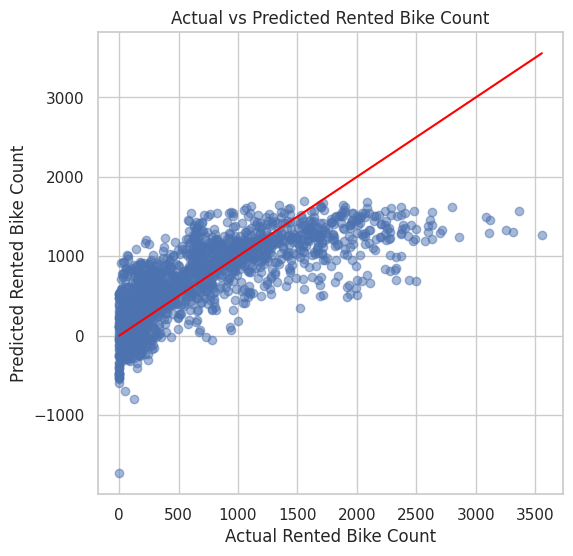

In [53]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.title("Actual vs Predicted Rented Bike Count")
plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.show()

## 11 - Kesimpulan

Dataset Seoul Bike Sharing Demand digunakan untuk memprediksi `Rented Bike Count` berdasarkan cuaca, waktu, musim, hari libur, dan status operasional. Dataset memiliki 8760 baris dan 14 kolom. Data tidak memiliki missing value dan memiliki 0 baris duplikat penuh.

EDA menunjukkan bahwa target `Rented Bike Count` cenderung miring ke kanan. Fitur numerik yang paling kuat positif hubungannya dengan target adalah `Temperature`, sedangkan rata-rata penyewaan tertinggi terjadi sekitar jam 18. Kolom kategori diubah menjadi numerik menggunakan `pd.get_dummies()`, dan kolom `Date` dihapus sebelum modeling.

Data dibagi menjadi 80% data train dan 20% data test. Berdasarkan evaluasi, MAE test bernilai sekitar 330.385, RMSE test sekitar 440.781, dan R2 test sekitar 0.534.